# Figure 4: Quantitative summary

This notebook generates **Figure 4** for the paper: a compact quantitative comparison of three repair strategies:

- **Center-fan**
- **Planar removed-part-aware**
- **Planar largest-hole-only**

The figure contains three bar charts:

1. **Closure**: mean target loop length after repair (lower is better)
2. **Patch complexity**: mean number of added faces (lower is better), with mean added-face quality shown as annotations
3. **Locality**: mean number of added faces outside the repair zone (lower is better), with face locality ratio shown as annotations

The script is written to be robust to slightly different summary CSV layouts. It searches for the required metrics by normalized names and then saves the final figure to `../results/vis/figure4_quantitative_summary.png`.

In [14]:
from pathlib import Path
import re
import math
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [15]:
# Resolve project directories relative to this notebook when possible.
# Expected project structure:
#   evaluation/figure4_quantitative_summary.ipynb
#   results/csv/...
#   results/vis/...

def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'results' / 'csv').exists():
            return candidate
    return start

try:
    NOTEBOOK_DIR = Path.cwd()
except NameError:
    NOTEBOOK_DIR = Path('.').resolve()

PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
CSV_DIR = PROJECT_ROOT / 'results' / 'csv'
VIS_DIR = PROJECT_ROOT / 'results' / 'vis'
VIS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('CSV dir:', CSV_DIR)
print('VIS dir:', VIS_DIR)

Project root: D:\MyJupyter\Works\3Dsegment
CSV dir: D:\MyJupyter\Works\3Dsegment\results\csv
VIS dir: D:\MyJupyter\Works\3Dsegment\results\vis


In [16]:
SUMMARY_FILES = {
    'Center-fan': CSV_DIR / 'baseline_center_fan_summary_locality.csv',
    'Planar removed-part-aware': CSV_DIR / 'baseline_planar_summary_locality.csv',
    'Planar largest-hole-only': CSV_DIR / 'baseline_planar_largest_hole_summary.csv',
}

for method, path in SUMMARY_FILES.items():
    print(f'{method}: {path} ->', 'FOUND' if path.exists() else 'MISSING')

Center-fan: D:\MyJupyter\Works\3Dsegment\results\csv\baseline_center_fan_summary_locality.csv -> FOUND
Planar removed-part-aware: D:\MyJupyter\Works\3Dsegment\results\csv\baseline_planar_summary_locality.csv -> FOUND
Planar largest-hole-only: D:\MyJupyter\Works\3Dsegment\results\csv\baseline_planar_largest_hole_summary.csv -> FOUND


In [17]:
def normalize_key(text: str) -> str:
    text = str(text).strip().lower()
    text = text.replace('_', ' ')
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_number(x) -> bool:
    try:
        float(x)
        return True
    except Exception:
        return False

def summary_csv_to_dict(path: Path) -> dict:
    df = pd.read_csv(path)
    out = {}

    # Case 1: canonical metric/value layout
    lowered = {c.lower(): c for c in df.columns}
    if 'metric' in lowered and 'value' in lowered:
        metric_col = lowered['metric']
        value_col = lowered['value']
        for _, row in df.iterrows():
            k = normalize_key(row[metric_col])
            v = row[value_col]
            if is_number(v):
                out[k] = float(v)
        return out

    # Case 2: two-column summary without explicit headers
    if df.shape[1] == 2:
        c0, c1 = df.columns[:2]
        metric_like = df[c0].astype(str).map(normalize_key)
        numeric_share = pd.to_numeric(df[c1], errors='coerce').notna().mean()
        if numeric_share > 0.5:
            for _, row in df.iterrows():
                if is_number(row[c1]):
                    out[normalize_key(row[c0])] = float(row[c1])
            return out

    # Case 3: one-row wide format
    if len(df) >= 1:
        row = df.iloc[0]
        for col in df.columns:
            v = row[col]
            if is_number(v):
                out[normalize_key(col)] = float(v)

    return out

def fetch_metric(summary_dict: dict, candidates: list[str]) -> float:
    norm_candidates = [normalize_key(c) for c in candidates]

    # exact candidate match first
    for cand in norm_candidates:
        if cand in summary_dict:
            return summary_dict[cand]

    # substring fallback
    for cand in norm_candidates:
        for k, v in summary_dict.items():
            if cand in k or k in cand:
                return v

    available = '\n  - ' + '\n  - '.join(sorted(summary_dict.keys()))
    raise KeyError(f'Could not find any of {candidates}. Available keys:{available}')

def load_all_summaries(file_map: dict) -> dict:
    summaries = {}
    for method, path in file_map.items():
        if not path.exists():
            raise FileNotFoundError(f'Missing summary CSV for {method}: {path}')
        summaries[method] = summary_csv_to_dict(path)
    return summaries

summaries = load_all_summaries(SUMMARY_FILES)
for method, s in summaries.items():
    print(f'\n[{method}]')
    for k, v in sorted(s.items()):
        print(f'  {k}: {v}')


[Center-fan]
  mean added face quality: 0.4010983870750632
  mean face locality ratio: 0.6785714285714286
  mean improvement: 0.6680639472884415
  mean min added face quality: 0.1901218757113802
  mean nearest loop len after: 0.0
  mean num added faces: 46.9
  mean num added faces inside zone: 32.3
  mean num added faces outside zone: 14.6
  mean num loops repaired: 1.8
  mean num new vertices: 1.8
  mean total loop len before: 0.6680639472884415
  num samples: 10.0
  num success: 10.0

[Planar removed-part-aware]
  mean added face quality: 0.4116370823251831
  mean face locality ratio: 0.6743589743589744
  mean improvement: 0.6680639472884415
  mean min added face quality: 0.2238335280718196
  mean nearest loop len after: 0.0
  mean num added faces: 37.0
  mean num added faces inside zone: 28.8
  mean num added faces outside zone: 8.2
  mean num loops repaired: 1.8
  mean num new vertices: 0.0
  mean total loop len before: 0.6680639472884415
  num samples: 10.0
  num success: 10.0

[

In [18]:
metric_aliases = {
    'closure_after': [
        'mean target loop length after repair',
        'target loop length after repair',
        'nearest loop len after',
        'mean nearest loop len after',
    ],
    'improvement': [
        'mean improvement',
        'improvement',
    ],
    'num_added_faces': [
        'mean number of added faces',
        'num added faces',
        'added faces',
    ],
    'mean_added_face_quality': [
        'mean added face quality',
        'added face quality',
        'mean added-face quality',
    ],
    'num_added_faces_outside_zone': [
        'mean added faces outside zone',
        'num added faces outside zone',
        'added faces outside zone',
    ],
    'face_locality_ratio': [
        'mean face locality ratio',
        'face locality ratio',
        'locality ratio',
    ],
}

records = []
for method, summary in summaries.items():
    records.append({
        'method': method,
        'closure_after': fetch_metric(summary, metric_aliases['closure_after']),
        'improvement': fetch_metric(summary, metric_aliases['improvement']),
        'num_added_faces': fetch_metric(summary, metric_aliases['num_added_faces']),
        'mean_added_face_quality': fetch_metric(summary, metric_aliases['mean_added_face_quality']),
        'num_added_faces_outside_zone': fetch_metric(summary, metric_aliases['num_added_faces_outside_zone']),
        'face_locality_ratio': fetch_metric(summary, metric_aliases['face_locality_ratio']),
    })

plot_df = pd.DataFrame(records)
plot_df

,method,closure_after,improvement,num_added_faces,mean_added_face_quality,num_added_faces_outside_zone,face_locality_ratio
0,Center-fan,0.000000,0.668064,46.9,0.401098,14.6,0.678571
1,Planar removed-part-aware,0.000000,0.668064,37.0,0.411637,8.2,0.674359
2,Planar largest-hole-only,0.572868,0.716773,46.2,0.334359,44.3,0.100000


In [19]:
# Optional: enforce a consistent method order
method_order = [
    'Center-fan',
    'Planar removed-part-aware',
    'Planar largest-hole-only',
]

plot_df['method'] = pd.Categorical(plot_df['method'], categories=method_order, ordered=True)
plot_df = plot_df.sort_values('method').reset_index(drop=True)
plot_df

,method,closure_after,improvement,num_added_faces,mean_added_face_quality,num_added_faces_outside_zone,face_locality_ratio
0,Center-fan,0.000000,0.668064,46.9,0.401098,14.6,0.678571
1,NaN,0.000000,0.668064,37.0,0.411637,8.2,0.674359
2,NaN,0.572868,0.716773,46.2,0.334359,44.3,0.100000


       method  closure_after  num_added_faces  mean_added_face_quality  \
0  Center-fan       0.000000             46.9                 0.401098   
1         NaN       0.000000             37.0                 0.411637   
2         NaN       0.572868             46.2                 0.334359   

   num_added_faces_outside_zone  face_locality_ratio  
0                          14.6             0.678571  
1                           8.2             0.674359  
2                          44.3             0.100000  
method                          category
closure_after                    float64
improvement                      float64
num_added_faces                  float64
mean_added_face_quality          float64
num_added_faces_outside_zone     float64
face_locality_ratio              float64
dtype: object


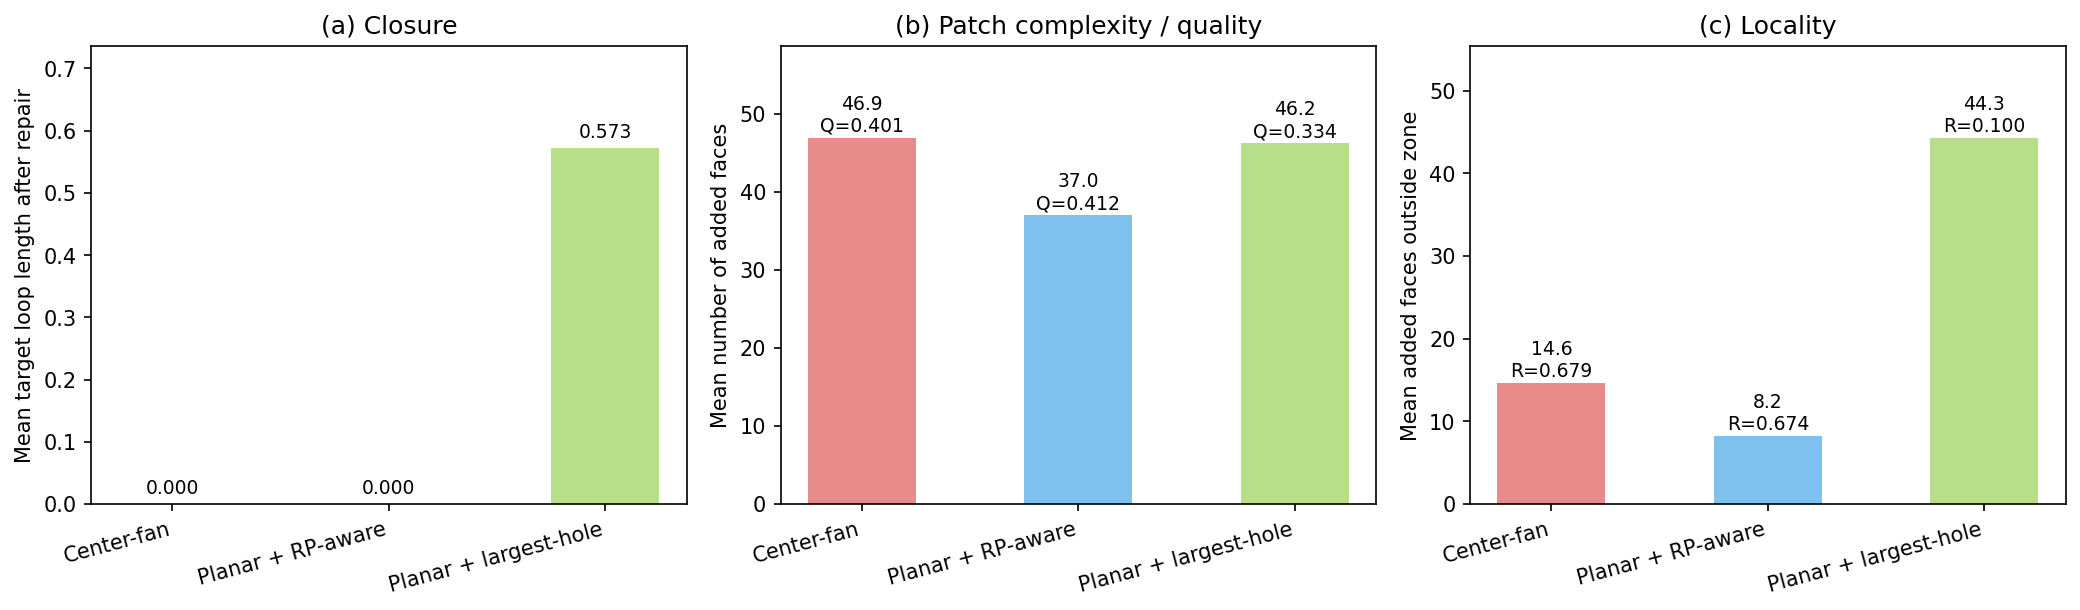

Saved: D:\MyJupyter\Works\3Dsegment\results\vis\figure4_quantitative_summary.png


In [22]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
# 先确保是纯数值
num_cols = [
    'closure_after',
    'num_added_faces',
    'mean_added_face_quality',
    'num_added_faces_outside_zone',
    'face_locality_ratio',
]
for c in num_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

print(plot_df[['method'] + num_cols])
print(plot_df.dtypes)

def fmt(x, digits=3):
    if pd.isna(x):
        return 'nan'
    return f'{x:.{digits}f}'

methods = plot_df['method'].astype(str).tolist()
methods = ['Center-fan', 'Planar + RP-aware', 'Planar + largest-hole']
x = list(range(len(methods)))

# 固定方法颜色（按行顺序）
method_colors = ['#e78b8b', '#7ec0ee', '#b7df8a']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) Closure
ax = axes[0]
bars = ax.bar(
    x,
    plot_df['closure_after'].fillna(0).values,
    width=0.5,
    color=method_colors
)
ax.set_title('(a) Closure')
ax.set_ylabel('Mean target loop length after repair')
ax.set_ylim(0, max(plot_df['closure_after']) * 1.25 + 0.02)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
for bar, val in zip(bars, plot_df['closure_after']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        fmt(val, 3),
        ha='center',
        va='bottom',
        fontsize=9
    )

# (b) Patch complexity / quality
ax = axes[1]
bars = ax.bar(
    x,
    plot_df['num_added_faces'].fillna(0).values,
    width=0.5,
    color=method_colors
)
ax.set_title('(b) Patch complexity / quality')
ax.set_ylabel('Mean number of added faces')
ax.set_ylim(0, max(plot_df['num_added_faces']) * 1.25 + 0.02)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
for bar, faces, q in zip(bars, plot_df['num_added_faces'], plot_df['mean_added_face_quality']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{fmt(faces, 1)}\nQ={fmt(q, 3)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# (c) Locality
ax = axes[2]
bars = ax.bar(
    x,
    plot_df['num_added_faces_outside_zone'].fillna(0).values,
    width=0.5,
    color=method_colors
)
ax.set_title('(c) Locality')
ax.set_ylabel('Mean added faces outside zone')
ax.set_ylim(0, max(plot_df['num_added_faces_outside_zone']) * 1.25 + 0.02)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
for bar, outside, ratio in zip(bars, plot_df['num_added_faces_outside_zone'], plot_df['face_locality_ratio']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{fmt(outside, 1)}\nR={fmt(ratio, 3)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

#fig.suptitle('Figure 4. Quantitative summary of repair performance', fontsize=14)
plt.tight_layout()

out_png = VIS_DIR / 'figure4_quantitative_summary.png'
fig.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', out_png)

## Notes

- Panel **(a)** focuses on closure using **mean target loop length after repair** (lower is better).
- Panel **(b)** uses **mean number of added faces** as the main bar value, and annotates **mean added-face quality** as `Q=...` above each bar. This helps show that the planar removed-part-aware baseline is cleaner than center-fan.
- Panel **(c)** uses **mean added faces outside the repair zone** as the main bar value, and annotates **face locality ratio** as `R=...`. This highlights the poor locality of the largest-hole-only baseline.
- If you want to switch panel (a) from `closure_after` to `improvement`, simply replace the plotted column in the plotting cell.